In [1]:
import numpy as np
import pandas as pd
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
import random
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, StopTrainingOnNoModelImprovement
from collections import deque

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Stronger determinism (may slow down)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cuda


Changes from v13: 1) updated HOLD scale penalty threshold to discourage more HOLD; 2) 85/15 split

Load + prep the event dataframe

In [3]:
# Load raw parquet
# raw = pd.read_parquet("DC_events_1h.parquet")
raw = pd.read_parquet("DC_events_1min.parquet")
print("raw shape:", raw.shape)
print(raw.head())
print(raw.isna().mean().sort_values(ascending=False).head(10)) 

raw shape: (136062, 29)
                              event   theta    ret_1h  ret_1d  ret_30d  \
t                                                                        
2019-07-09 14:25:00+00:00  down_dcc  0.0025       NaN     NaN      NaN   
2019-07-09 14:56:00+00:00    up_dcc  0.0025       NaN     NaN      NaN   
2019-07-09 14:59:00+00:00  down_dcc  0.0025       NaN     NaN      NaN   
2019-07-09 15:07:00+00:00    up_dcc  0.0025  0.003583     NaN      NaN   
2019-07-09 15:35:00+00:00  down_dcc  0.0025  0.019365     NaN      NaN   

                           ret_60d    vol_1h    vol_1d   vol_30d   vol_60d  \
t                                                                            
2019-07-09 14:25:00+00:00      NaN  0.001043  0.001043  0.001043  0.001043   
2019-07-09 14:56:00+00:00      NaN  0.000861  0.000861  0.000861  0.000861   
2019-07-09 14:59:00+00:00      NaN  0.000936  0.000936  0.000936  0.000936   
2019-07-09 15:07:00+00:00      NaN  0.001032  0.000982  0.000982  0

In [4]:
PATH = "DC_events_1min.parquet"

REWARD_COL = "ret_next_confirm"  # scaled
RAW_RETURN_COL = "ret_next_confirm_raw"

# Use durations instead of raw datetimes in state
# Use stationary transforms instead (log-ratios/returns) to reduce train->test distribution shift.
STATE_COLS_SAFE = [
    "event_code",                      # encoded from event (object)
    "theta",
    "log_p_ratio_to_prior",            # log(p_t / p_prior_extreme)
    "log_ret_confirm",                 # log return between confirmations (proxy trend)
    "dcc_move_log",
    "dcc_move_ret",
    "dcc_move_abs_ret",
    "n_obs_between_priorextreme_confirm",
    "dcc_dir",                         # already int64 in your data
    "dt_prior_to_confirm_sec",          # derived from timestamps

    # --- Prior-period returns (assumed known at t_confirm) ---
    "ret_1h",
    "ret_1d",
    "ret_30d",
    "ret_60d",

    # --- Prior-period volatility (assumed computed from history up to t_confirm) ---
    "vol_1h",
    "vol_1d",
    "vol_30d",
    "vol_60d",

    # --- Prior-period average tick volume (history up to t_confirm) ---
    "tickvol_avg_1h",
    "tickvol_avg_1d",
    "tickvol_avg_30d",
    "tickvol_avg_60d",
]

def load_dc_events_for_rl(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path).copy()

    # Sort by decision time
    df = df.sort_values("t_confirm").reset_index(drop=True)

    # Encode categorical event -> numeric code
    df["event_code"] = df["event"].astype("category").cat.codes.astype(np.float32)

    # Ensure timestamps are datetime (they are in your file)
    df["t_prior_extreme"] = pd.to_datetime(df["t_prior_extreme"], errors="coerce")
    df["t_confirm"] = pd.to_datetime(df["t_confirm"], errors="coerce")

    # Numeric time-delta feature (seconds)
    df["dt_prior_to_confirm_sec"] = (df["t_confirm"] - df["t_prior_extreme"]).dt.total_seconds()

    # Coerce numeric columns that should be numeric (NOT the raw event string)
    # Note: we keep p_t and p_prior_extreme in df for reward construction, but we do NOT feed
    # raw price levels into the policy state (see STATE_COLS_SAFE).
    numeric_cols = [
        "theta",
        "p_prior_extreme", "p_t",
        "dcc_move_log", "dcc_move_ret", "dcc_move_abs_ret",
        "n_obs_between_priorextreme_confirm",
        "dcc_dir",
        "dt_prior_to_confirm_sec",
        "ret_1h", "ret_1d", "ret_30d", "ret_60d",
        "vol_1h", "vol_1d", "vol_30d", "vol_60d",
        "tickvol_avg_1h", "tickvol_avg_1d", "tickvol_avg_30d", "tickvol_avg_60d",
        REWARD_COL,
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    # --- Recommended reward: net return from this decision (t_confirm) to next decision ---
    # This matches "agent can only change position at confirmations".
    # Keep BOTH:
    #   - ret_next_confirm_raw: used for equity compounding / baselines
    #   - ret_next_confirm     : scaled, used as PPO learning signal

    df["ret_next_confirm_raw"] = df["p_t"].shift(-1) / df["p_t"] - 1.0
    df["ret_next_confirm"] = 100.0 * df["ret_next_confirm_raw"]   # scaled reward signal (e.g., ~bps*100)

    # --- Stationary state transforms (reduce train->test price-level shift) ---
    # Avoid feeding raw price levels into the policy; use log-ratios/returns instead.
    df["log_p_ratio_to_prior"] = np.log(df["p_t"] / df["p_prior_extreme"])
    df["log_ret_confirm"] = np.log(df["p_t"]).diff()

    # Ensure numeric (defensive)
    df["ret_next_confirm_raw"] = pd.to_numeric(df["ret_next_confirm_raw"], errors="coerce")
    df["ret_next_confirm"] = pd.to_numeric(df["ret_next_confirm"], errors="coerce")
    df["log_p_ratio_to_prior"] = pd.to_numeric(df["log_p_ratio_to_prior"], errors="coerce")
    df["log_ret_confirm"] = pd.to_numeric(df["log_ret_confirm"], errors="coerce")

    # Drop rows missing required state/reward inputs
    df = df.dropna(subset=STATE_COLS_SAFE + [REWARD_COL]).reset_index(drop=True)
    return df


df = load_dc_events_for_rl(PATH)
print("df shape:", df.shape)
print("reward non-null:", df[REWARD_COL].notna().sum())
print(df[STATE_COLS_SAFE + [REWARD_COL]].head())

df shape: (131105, 35)
reward non-null: 131105
   event_code   theta  log_p_ratio_to_prior  log_ret_confirm  dcc_move_log  \
0         0.0  0.0025             -0.003140        -0.003140     -0.003140   
1         1.0  0.0025              0.002666         0.002379      0.002666   
2         0.0  0.0025             -0.002570        -0.002570     -0.002570   
3         1.0  0.0025              0.003317         0.000953      0.003317   
4         0.0  0.0025             -0.003365        -0.000227     -0.003365   

   dcc_move_ret  dcc_move_abs_ret  n_obs_between_priorextreme_confirm  \
0     -0.003136          0.003136                                20.0   
1      0.002669          0.002669                                 5.0   
2     -0.002567          0.002567                                17.0   
3      0.003323          0.003323                                 2.0   
4     -0.003359          0.003359                                28.0   

   dcc_dir  dt_prior_to_confirm_sec  ...   re

### Custom event-based trading env (short/hold/long)

In [5]:
# Reward shaping (aggregate)
# We combine:
#  - downside penalty on per-step PnL
#  - rolling drawdown penalty on prior X decisions
# into ONE aggregate reward function (see env.step).
USE_AGG_REWARD = True

# Legacy toggle: whether to include the per-step downside penalty term in the aggregate reward
USE_DOWNSIDE_PENALTY = True

PNL_SCALE = 100.0          # scales linear pnl term (to bring rewards to O(1))
DOWNSIDE_PENALTY = 50.0    # penalizes negative pnl per step (quadratic)

# Option C: rolling drawdown penalty based on PRIOR X decisions
# If rolling cumulative PnL over the last X steps drops below -5%, add extra penalty.
USE_ROLLING_DD_PENALTY = True
ROLL_WINDOW_X = 50              # number of prior decisions to look back
ROLL_DD_THRESHOLD = -0.03       # -5% cumulative PnL threshold (over the rolling window)
ROLL_DD_PENALTY = 25.0          # strength of penalty (increase to discourage large drawdowns)
ROLL_DD_PENALTY_POW = 2.0       # 1.0 linear, 2.0 quadratic penalty growth

# Option D: dynamic HOLD penalty (discourage staying flat when signal is strong)
# HOLD is action==1 in this env (flat/no exposure).
USE_HOLD_PENALTY = True
HOLD_PENALTY = 0.02              # max penalty per step when strength==1
HOLD_SIGNAL_SCALE = 0.01         # abs(scaled_r) level at which HOLD penalty reaches max (tune)

class DCEventTradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        df: pd.DataFrame,
        state_cols: list[str],
        reward_col: str = REWARD_COL,
        raw_return_col: str = RAW_RETURN_COL,
        # Option B
        use_downside_penalty: bool = True,
        pnl_scale: float = 100.0,
        downside_penalty: float = 50.0,
        # Option C
        use_rolling_dd_penalty: bool = True,
        roll_window_x: int = 20,
        roll_dd_threshold: float = -0.05,
        roll_dd_penalty: float = 50.0,
        roll_dd_penalty_pow: float = 2.0,
        # Option D
        use_hold_penalty: bool = False,
        hold_penalty: float = 0.02,
        hold_signal_scale: float = 0.05,
        # NEW: make reward-mode explicit (avoid global flags)
        use_agg_reward: bool = True,
    ):
        super().__init__()

        self.df = df.reset_index(drop=True)
        self.state_cols = list(state_cols)
        self.reward_col = reward_col
        self.raw_return_col = raw_return_col

        # Pre-extract arrays
        self.X = self.df[self.state_cols].astype(np.float32).values
        self.y = self.df[self.reward_col].astype(np.float32).values
        self.raw_r = self.df[self.raw_return_col].astype(np.float32).values

        # Reward shaping config
        self.use_agg_reward = bool(use_agg_reward)

        self.use_downside_penalty = bool(use_downside_penalty)
        self.pnl_scale = float(pnl_scale)
        self.downside_penalty = float(downside_penalty)

        self.use_rolling_dd_penalty = bool(use_rolling_dd_penalty)
        self.roll_window_x = int(max(1, roll_window_x))
        self.roll_dd_threshold = float(roll_dd_threshold)
        self.roll_dd_penalty = float(roll_dd_penalty)
        self.roll_dd_penalty_pow = float(roll_dd_penalty_pow)
        self._recent_pnl = deque(maxlen=self.roll_window_x)

        self.use_hold_penalty = bool(use_hold_penalty)
        self.hold_penalty = float(hold_penalty)
        self.hold_signal_scale = float(hold_signal_scale) if float(hold_signal_scale) > 0 else 1.0

        # Action mapping: 0=SHORT, 1=HOLD(flat), 2=LONG
        self.action_to_pos = {0: -1.0, 1: 0.0, 2: 1.0}

        # Obs = state + current position
        obs_dim = self.X.shape[1] + 1
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)

        self.i = 0
        self.pos = 0.0
        self.equity = 1.0
        self.episode_end = len(self.X) 

    def _obs(self) -> np.ndarray:
        return np.concatenate([self.X[self.i], np.array([self.pos], dtype=np.float32)]).astype(np.float32)

    def reset(self, seed=None, options=None):
        """Reset the environment.

        Option 2 support: random-start evaluation episodes.
        You can pass:
          options={"start_idx": i0, "horizon": H}
        so that the episode starts at i=i0 and terminates after H steps.

        Training can keep the default start_idx=0, horizon=None.
        """
        super().reset(seed=seed)

        options = options or {}
        start_idx = int(options.get("start_idx", 0) or 0)
        horizon = options.get("horizon", None)

        # Clamp start index
        if start_idx < 0:
            start_idx = 0
        if start_idx >= len(self.X):
            start_idx = max(0, len(self.X) - 1)

        self.i = start_idx
        self.pos = 0.0
        self.equity = 1.0
        self._recent_pnl.clear()

        if horizon is None:
            self.episode_end = len(self.X)
        else:
            H = int(horizon)
            if H <= 0:
                H = 1
            self.episode_end = min(len(self.X), self.i + H)

        return self._obs(), {}

    def step(self, action: int):
        idx = self.i  # keep for logging/debug

        a = int(action)
        new_pos = float(self.action_to_pos[a])

        # --- (unchanged timing) economic pnl over idx->idx+1 uses NEW position
        raw_r = float(self.raw_r[idx])
        pnl = new_pos * raw_r

        # PPO label (for HOLD penalty strength proxy)
        scaled_r = float(self.y[idx])

        # Rolling cumulative pnl over PRIOR X decisions
        roll_cum_pnl_prior = np.nan
        if len(self._recent_pnl) > 0:
            arr_prior = np.asarray(self._recent_pnl, dtype=float)
            roll_cum_pnl_prior = float(np.prod(1.0 + arr_prior) - 1.0)

        lin_term = self.pnl_scale * pnl
        downside_pen = self.downside_penalty * max(0.0, -pnl) ** 2 if self.use_downside_penalty else 0.0

        roll_dd_pen = 0.0
        if self.use_rolling_dd_penalty and np.isfinite(roll_cum_pnl_prior):
            breach = max(0.0, self.roll_dd_threshold - roll_cum_pnl_prior)
            if breach > 0:
                roll_dd_pen = float(self.roll_dd_penalty * (breach ** self.roll_dd_penalty_pow))

        if self.use_agg_reward:
            reward = float(lin_term - downside_pen - roll_dd_pen)
        else:
            # legacy fallback
            reward = float(new_pos * scaled_r)

        # HOLD penalty: check by position==0 to avoid index-coupling
        hold_pen = 0.0
        if self.use_hold_penalty and (new_pos == 0.0):
            strength = min(1.0, abs(scaled_r) / self.hold_signal_scale) if self.hold_signal_scale > 0 else 1.0
            hold_pen = float(self.hold_penalty * strength)
            reward -= hold_pen

        # Update buffer AFTER computing prior-window penalty
        self._recent_pnl.append(float(pnl))

        # Update equity
        self.equity *= (1.0 + pnl)

        # Update position then advance time
        self.pos = new_pos
        self.i += 1

        terminated = self.i >= getattr(self, "episode_end", len(self.X))
        truncated = False

        # Safe obs on terminal
        if terminated:
            obs = np.zeros(self.observation_space.shape, dtype=np.float32)
        else:
            obs = self._obs()

        info = {
            "idx": int(idx),
            "action": int(a),
            "new_pos": float(new_pos),
            "pos": float(self.pos),
            "equity": float(self.equity),
            "reward_input": float(scaled_r),
            "ret_next_confirm_raw": float(raw_r),
            "pnl": float(pnl),
            "reward": float(reward),
            "reward_lin": float(lin_term),
            "downside_pen": float(downside_pen),
            "roll_cum_pnl_prior": float(roll_cum_pnl_prior) if np.isfinite(roll_cum_pnl_prior) else np.nan,
            "roll_dd_pen": float(roll_dd_pen),
            "hold_pen": float(hold_pen),
            "os_after_ret": float(self.df.loc[idx, "os_after_ret"]) if "os_after_ret" in self.df.columns else np.nan,
            "ret_next_confirm": float(self.df.loc[idx, "ret_next_confirm"]) if "ret_next_confirm" in self.df.columns else np.nan,
        }

        return obs, reward, terminated, truncated, info

### Train PPO (Stable-Baselines3)

In [6]:
# Early stopping setup:
# - Create a VALIDATION split from the tail of the training window (time-ordered)
# - Evaluate periodically on validation and stop if no improvement for a while
VAL_FRAC = 0.15          # last 15% of the training window used as validation
EVAL_FREQ = 10_000       # evaluate every N training timesteps
PATIENCE_EVALS = 15       # stop after this many evals w/ no improvement
MIN_EVALS = 5            # don't stop too early

n = len(df)
n_train = int(n * 0.85)  # first 80% train (time order), last 20% test
train_full_df = df.iloc[:n_train].copy()
test_df = df.iloc[n_train:].copy()

# Validation split from the TAIL of train_full_df (still time-ordered)
n_val = max(1, int(len(train_full_df) * VAL_FRAC))
train_df = train_full_df.iloc[:-n_val].copy()
val_df = train_full_df.iloc[-n_val:].copy()

train_env = DummyVecEnv([
    lambda: DCEventTradingEnv(
        train_df,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        # Option C: rolling drawdown penalty
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        # Option D: dynamic HOLD penalty
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
    )
])
# Normalize observations for more stable learning (still recommended, even after using stationary transforms)
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=False, clip_obs=10.0)
train_env.seed(SEED)

# Validation env (NO stats updating; we will sync obs_rms from train_env during training)
val_env = DummyVecEnv([
    lambda: DCEventTradingEnv(
        val_df,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        # Option C: rolling drawdown penalty
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        # Option D: dynamic HOLD penalty
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
    )
])
val_env = VecNormalize(val_env, training=False, norm_obs=True, norm_reward=False, clip_obs=10.0)
val_env.seed(SEED + 1)
val_env.obs_rms = train_env.obs_rms

class SyncVecNormalizeCallback(BaseCallback):
    """Keeps eval_env VecNormalize stats aligned with train_env during training."""
    def __init__(self, train_env, eval_env, verbose=0):
        super().__init__(verbose)
        self.train_env = train_env
        self.eval_env = eval_env

    def _on_step(self) -> bool:
        # Copy running mean/var of observations
        self.eval_env.obs_rms = self.train_env.obs_rms
        return True

# Early stopping: stop if validation mean episode reward doesn't improve
stop_cb = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=PATIENCE_EVALS,
    min_evals=MIN_EVALS,
    verbose=1,
)

eval_cb = EvalCallback(
    val_env,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=1,          # 1 long episode = one pass over val_df
    deterministic=True,
    callback_after_eval=stop_cb,
    best_model_save_path="./sb3_best",
    log_path="./sb3_logs",
    verbose=1,
)

sync_cb = SyncVecNormalizeCallback(train_env, val_env)

# Network sizing (bigger nets/batches can help GPU utilization)
NET_ARCH = [256, 256]  # try [128,128] (CPU) or [256,256]/[512,512] (GPU)

model = PPO(
    "MlpPolicy",  # plain feed-forward neural network (MLP)
    train_env,
    policy_kwargs=dict(net_arch=NET_ARCH),
    verbose=1,
    device=DEVICE,
    learning_rate=3e-4, # 3e-4
    n_steps=4096, #2048
    batch_size=512,  # try 512/1024 if using GPU + larger NET_ARCH
    gamma=0.995, # 0.99
    gae_lambda=0.90,
    ent_coef=0.001,  # encourages exploring LONG/SHORT vs collapsing to HOLD; # 0.0003
    clip_range=0.1,
    vf_coef=0.8, #0.5
    target_kl=0.01, 
    seed=SEED
)

model.learn(
    total_timesteps=200_000,  # upper bound; early stopping may stop sooner
    callback=[sync_cb, eval_cb],
)

# quick eval (equity compounding via underlying env.equity)
# IMPORTANT: apply the same observation normalization stats at test time

test_env = DummyVecEnv([
    lambda: DCEventTradingEnv(
        test_df,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        # Option C: rolling drawdown penalty
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        # Option D: dynamic HOLD penalty
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
    )
])
test_env = VecNormalize(test_env, training=False, norm_obs=True, norm_reward=False)
test_env.seed(SEED + 2)
test_env.obs_rms = train_env.obs_rms

obs = test_env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, r, dones, infos = test_env.step(action)
    done = bool(dones[0])

print("Test toy equity:", test_env.venv.envs[0].equity)

Using cuda device


/opt/conda/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 615  |
|    iterations      | 1    |
|    time_elapsed    | 6    |
|    total_timesteps | 4096 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 604         |
|    iterations           | 2           |
|    time_elapsed         | 13          |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.001770064 |
|    clip_fraction        | 0.0596      |
|    clip_range           | 0.1         |
|    entropy_loss         | -1.1        |
|    explained_variance   | -0.0606     |
|    learning_rate        | 0.0003      |
|    loss                 | 0.433       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00292    |
|    value_loss           | 0.561       |
-----------------------------------------


/opt/conda/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=10000, episode_reward=-66.15 +/- 0.00
Episode length: 16715.00 +/- 0.00
------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 1.67e+04     |
|    mean_reward          | -66.1        |
| time/                   |              |
|    total_timesteps      | 10000        |
| train/                  |              |
|    approx_kl            | 0.0019383924 |
|    clip_fraction        | 0.0676       |
|    clip_range           | 0.1          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 0.0714       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.48         |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.00294     |
|    value_loss           | 0.656        |
------------------------------------------
New best mean reward!
------------------------------
| time/              |       |
|    fps             | 343   |
|    iterations     

### Evaluation summary

In [7]:
ACTION_NAME = {0: "SHORT", 1: "HOLD", 2: "LONG"}  # HOLD = flat/no exposure

def _name_from_pos(p: float) -> str:
    if p > 0:
        return "LONG"
    if p < 0:
        return "SHORT"
    return "HOLD"


def evaluate_with_action_stats(model, env, deterministic=True, max_steps=None):
    """Works with a VecEnv (DummyVecEnv/VecNormalize) of size 1."""
    obs = env.reset()
    done = False

    actions, rewards, os_rets, positions, raw_rets = [], [], [], [], []

    steps = 0
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, r, dones, infos = env.step(action)
        done = bool(dones[0])

        a0 = int(action[0])
        info0 = infos[0]

        pos0 = float(info0.get("pos", np.nan))
        raw0 = float(info0.get("ret_next_confirm_raw", np.nan))

        actions.append(a0)
        rewards.append(float(r[0]))
        os_rets.append(float(info0.get("os_after_ret", np.nan)))
        positions.append(pos0)
        raw_rets.append(raw0)

        steps += 1
        if max_steps is not None and steps >= max_steps:
            break

    df_rollout = pd.DataFrame({
        "action": actions,
        "reward": rewards,
        "ret_next_confirm_raw": raw_rets,
        "os_after_ret": os_rets,
        "pos": positions,
    })

    # Action name from executed position (not from action index)
    df_rollout["action_name"] = df_rollout["pos"].apply(lambda p: _name_from_pos(float(p)) if np.isfinite(p) else "NA")

    # Profit fraction per step using RAW return
    df_rollout["pnl_frac_raw"] = df_rollout["pos"].astype(float) * df_rollout["ret_next_confirm_raw"].astype(float)

    per_action = (
        df_rollout
        .groupby("action_name")
        .agg(
            n=("reward", "size"),
            freq=("reward", lambda x: len(x) / len(df_rollout) if len(df_rollout) else np.nan),
            avg_reward=("reward", "mean"),
            med_reward=("reward", "median"),
            win_rate=("reward", lambda x: float(np.mean(np.array(x) > 0))),
            avg_pnl_frac_raw=("pnl_frac_raw", "mean"),
            med_pnl_frac_raw=("pnl_frac_raw", "median"),
            pnl_win_rate_raw=("pnl_frac_raw", lambda x: float(np.mean(np.array(x) > 0))),
            avg_raw_ret_unadj=("ret_next_confirm_raw", "mean"),
        )
        .sort_index()
    )

    vc = df_rollout["action"].value_counts(normalize=True)
    action_entropy = float(-(vc * np.log(vc + 1e-12)).sum()) if len(vc) else np.nan

    overall = {
        "n_steps": len(df_rollout),
        "avg_reward": float(df_rollout["reward"].mean()) if len(df_rollout) else np.nan,
        "win_rate": float((df_rollout["reward"] > 0).mean()) if len(df_rollout) else np.nan,
        "action_entropy": action_entropy,
    }

    return df_rollout, per_action, overall

In [8]:
def evaluate_random_start_episodes(
    model,
    vecnorm_env,
    n_episodes: int = 10,
    horizon: int = 2000,
    deterministic: bool = True,
    seed: int = 123,
):
    """Evaluate a policy on multiple random-start windows.

    Important: vecnorm_env should be VecNormalize(training=False) with obs_rms copied from train_env.
    We step the underlying base env directly so we can pass reset(options={...}).
    """
    base_env = vecnorm_env.venv.envs[0]
    T = len(base_env.df)
    H = int(horizon)
    if H <= 0:
        H = 1

    max_start = max(0, T - H - 1)
    rng = np.random.default_rng(seed)

    ep_rewards = []
    ep_equity_end = []

    for _ in range(int(n_episodes)):
        i0 = int(rng.integers(0, max_start + 1)) if max_start > 0 else 0

        obs0, _ = base_env.reset(options={"start_idx": i0, "horizon": H})
        obs = vecnorm_env.normalize_obs(obs0[None, :])  # add batch dim

        done = False
        total_r = 0.0
        steps = 0
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            a = int(action[0])

            obs1, r, term, trunc, info = base_env.step(a)
            total_r += float(r)
            steps += 1

            done = bool(term) or bool(trunc)
            if not done:
                obs = vecnorm_env.normalize_obs(obs1[None, :])

        ep_rewards.append(total_r)
        ep_equity_end.append(float(getattr(base_env, "equity", np.nan)))

    return {
        "n_episodes": int(n_episodes),
        "horizon": int(H),
        "mean_total_reward": float(np.mean(ep_rewards)) if len(ep_rewards) else np.nan,
        "std_total_reward": float(np.std(ep_rewards)) if len(ep_rewards) else np.nan,
        "mean_equity_end": float(np.nanmean(ep_equity_end)) if len(ep_equity_end) else np.nan,
        "std_equity_end": float(np.nanstd(ep_equity_end)) if len(ep_equity_end) else np.nan,
    }

In [9]:
_eval_env = DummyVecEnv([
    lambda: DCEventTradingEnv(
        test_df,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        # Option C: rolling drawdown penalty
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        # Option D: dynamic HOLD penalty
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
    )
])
_eval_env = VecNormalize(_eval_env, training=False, norm_obs=True, norm_reward=False)
_eval_env.seed(SEED + 3)
_eval_env.obs_rms = train_env.obs_rms

df_rollout, per_action, overall = evaluate_with_action_stats(model, _eval_env, deterministic=True)

print("=== Overall ===")
for k, v in overall.items():
    print(f"{k}: {v}")

print("\n=== Per-action stats ===")
print(per_action)

print("\nFirst few decisions:")
print(df_rollout.head(10))

# Optional: Overshoot-sign confusion-style view (diagnostic)
df_rollout["os_sign"] = np.sign(df_rollout["os_after_ret"]).astype(int)  # -1,0,1
conf = pd.crosstab(df_rollout["action_name"], df_rollout["os_sign"], normalize="index")
print("\nAction vs sign(os_after_ret) (row-normalized):")
print(conf)

=== Overall ===
n_steps: 19666
avg_reward: 0.004311979618700299
win_rate: 0.5044747279568799
action_entropy: 0.6616949830684831

=== Per-action stats ===
                 n      freq  avg_reward  med_reward  win_rate  \
action_name                                                      
HOLD           100  0.005085   -0.019849   -0.020000  0.000000   
LONG         13142  0.668260    0.005582    0.003809  0.503424   
SHORT         6424  0.326655    0.002089    0.015609  0.514477   

             avg_pnl_frac_raw  med_pnl_frac_raw  pnl_win_rate_raw  \
action_name                                                         
HOLD                 0.000000          0.000000          0.000000   
LONG                 0.000063          0.000039          0.503652   
SHORT                0.000030          0.000163          0.515411   

             avg_raw_ret_unadj  
action_name                     
HOLD                  0.000476  
LONG                  0.000063  
SHORT                -0.000030  

Fir

### Execution log

In [10]:
# - Agent chooses an action at each t_confirm.
# - P&L is realized over the interval until the NEXT t_confirm.
# - Entry = (t_confirm_i, p_t_i); Exit = (t_confirm_{i+1}, p_t_{i+1})
T_roll = len(df_rollout)
T_max  = len(test_df) - 1              # max # of intervals you can form inside test_df
T_exec = min(T_roll, T_max)            # <-- key fix

# Keep only the part that can be matched to entry/exit prices
df_roll_exec = df_rollout.iloc[:T_exec].copy()
_test_exec   = test_df.iloc[:T_exec + 1].copy()   # need +1 for exits

# Entry/exit times & prices
entry_time  = pd.to_datetime(_test_exec["t_confirm"].iloc[:T_exec].values)
exit_time   = pd.to_datetime(_test_exec["t_confirm"].iloc[1:T_exec+1].values)
entry_price = _test_exec["p_t"].iloc[:T_exec].astype(float).values
exit_price  = _test_exec["p_t"].iloc[1:T_exec+1].astype(float).values

# Net return over interval
ret_interval = (exit_price / entry_price) - 1.0    # length = T_exec

# Executed position from rollout (source of truth)
pos_vec = df_roll_exec["pos"].astype(float).values  # length = T_exec

# P&L fraction per interval
pnl_frac = pos_vec * ret_interval                   # now same length

# Equity path
equity_start = np.empty(T_exec, dtype=float)
equity_end   = np.empty(T_exec, dtype=float)
E = 1.0
for i in range(T_exec):
    equity_start[i] = E
    E *= (1.0 + pnl_frac[i])
    equity_end[i] = E

pnl_abs = equity_end - equity_start

exec_log = pd.DataFrame({
    "idx": np.arange(T_exec, dtype=int),
    "action": df_roll_exec["action"].values,
    "action_name": df_roll_exec["action_name"].values,
    "position": pos_vec,
    "entry_time": entry_time,
    "exit_time": exit_time,
    "entry_price": entry_price,
    "exit_price": exit_price,
    "ret_interval": ret_interval,
    "pnl_frac": pnl_frac,
    "equity_start": equity_start,
    "equity_end": equity_end,
    "pnl_abs": pnl_abs,
})

print("\n=== Execution log (head) ===")
print(exec_log.head(15))

print("\n=== Execution summary by action ===")
print(
    exec_log.groupby("action_name")
            .agg(
                n=("pnl_frac", "size"),
                avg_pnl_frac=("pnl_frac", "mean"),
                win_rate=("pnl_frac", lambda x: float(np.mean(np.array(x) > 0))),
                avg_pnl_abs=("pnl_abs", "mean"),
            )
            .sort_index()
)


=== Execution log (head) ===
    idx  action action_name  position          entry_time           exit_time  \
0     0       2        LONG       1.0 2024-07-20 06:35:00 2024-07-20 07:02:00   
1     1       2        LONG       1.0 2024-07-20 07:02:00 2024-07-20 08:37:00   
2     2       2        LONG       1.0 2024-07-20 08:37:00 2024-07-20 08:59:00   
3     3       2        LONG       1.0 2024-07-20 08:59:00 2024-07-20 09:41:00   
4     4       2        LONG       1.0 2024-07-20 09:41:00 2024-07-20 10:08:00   
5     5       2        LONG       1.0 2024-07-20 10:08:00 2024-07-20 10:24:00   
6     6       2        LONG       1.0 2024-07-20 10:24:00 2024-07-20 10:31:00   
7     7       2        LONG       1.0 2024-07-20 10:31:00 2024-07-20 10:50:00   
8     8       2        LONG       1.0 2024-07-20 10:50:00 2024-07-20 11:14:00   
9     9       2        LONG       1.0 2024-07-20 11:14:00 2024-07-20 11:35:00   
10   10       2        LONG       1.0 2024-07-20 11:35:00 2024-07-20 11:45:00  

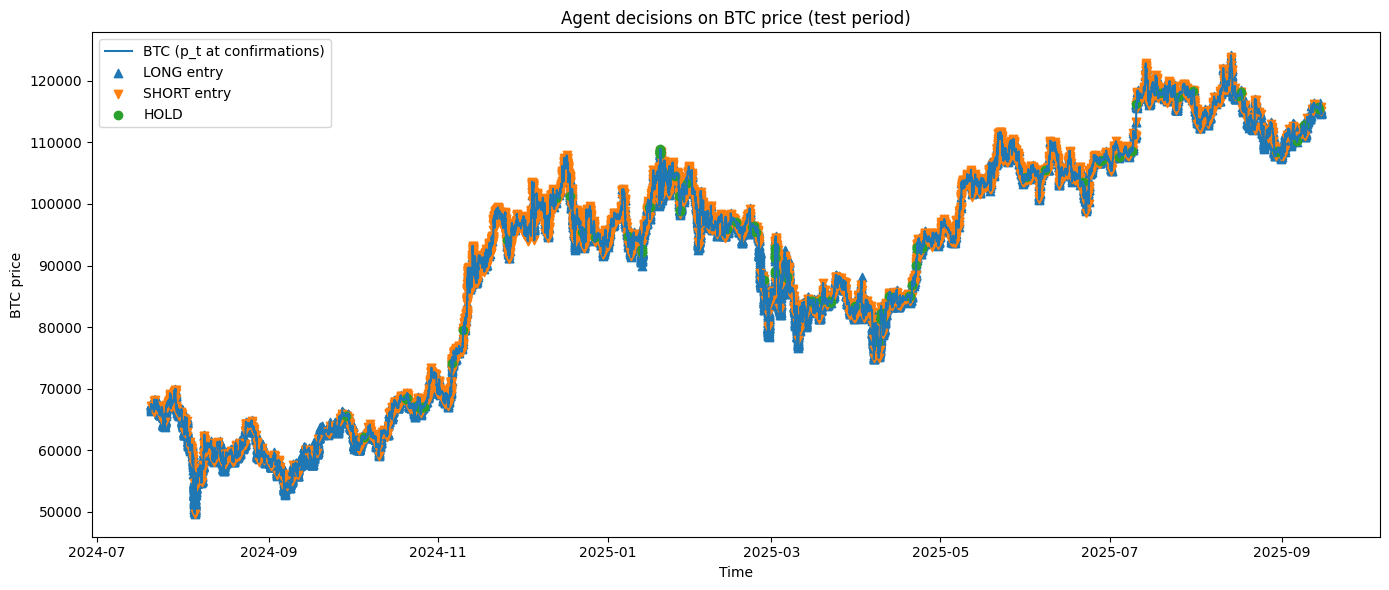

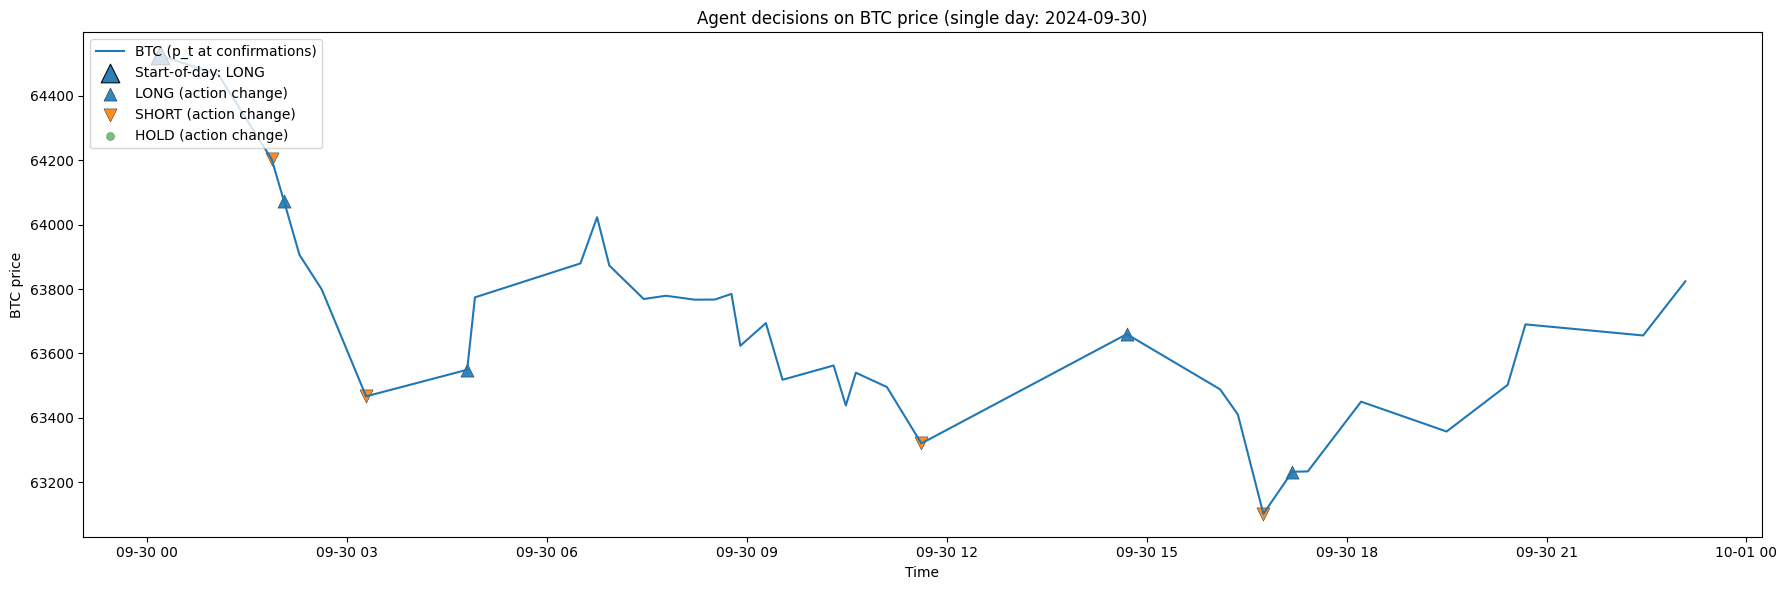

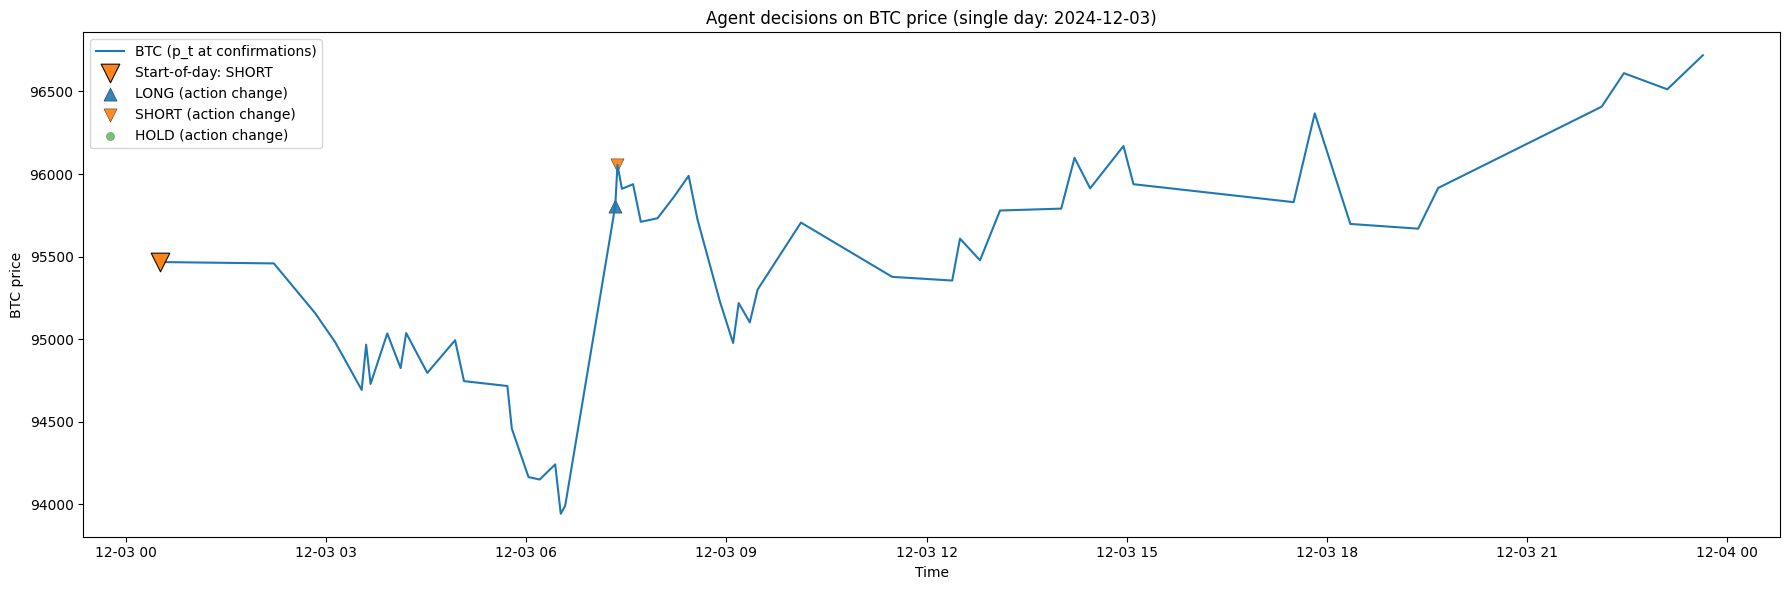

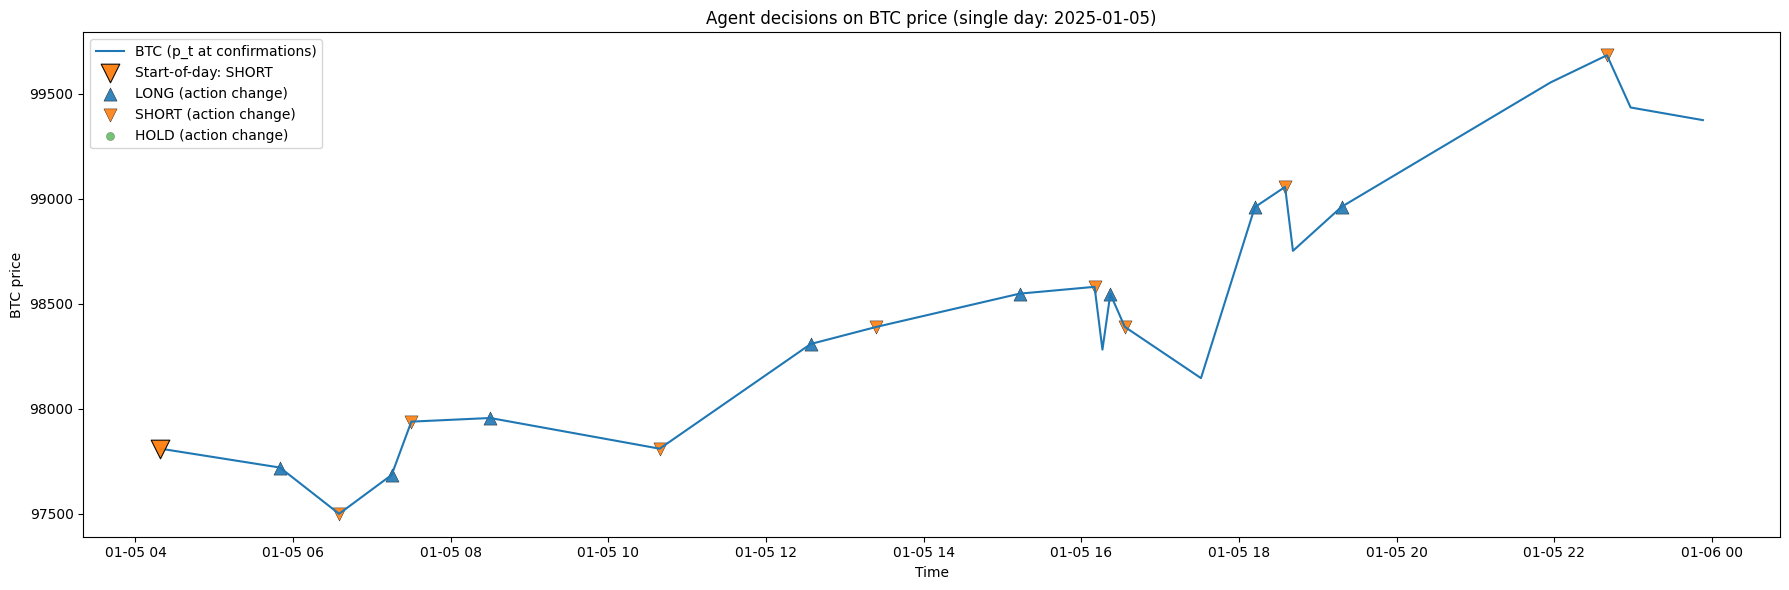

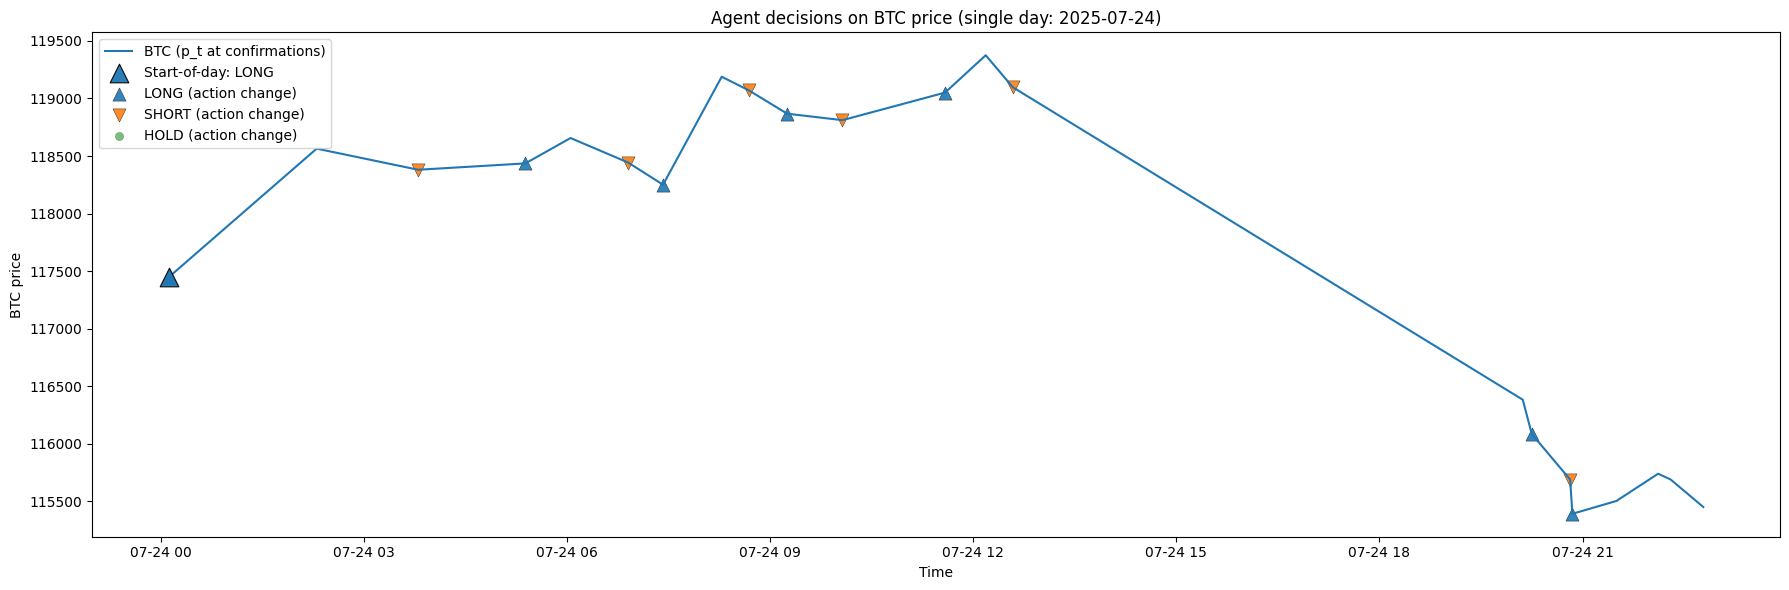

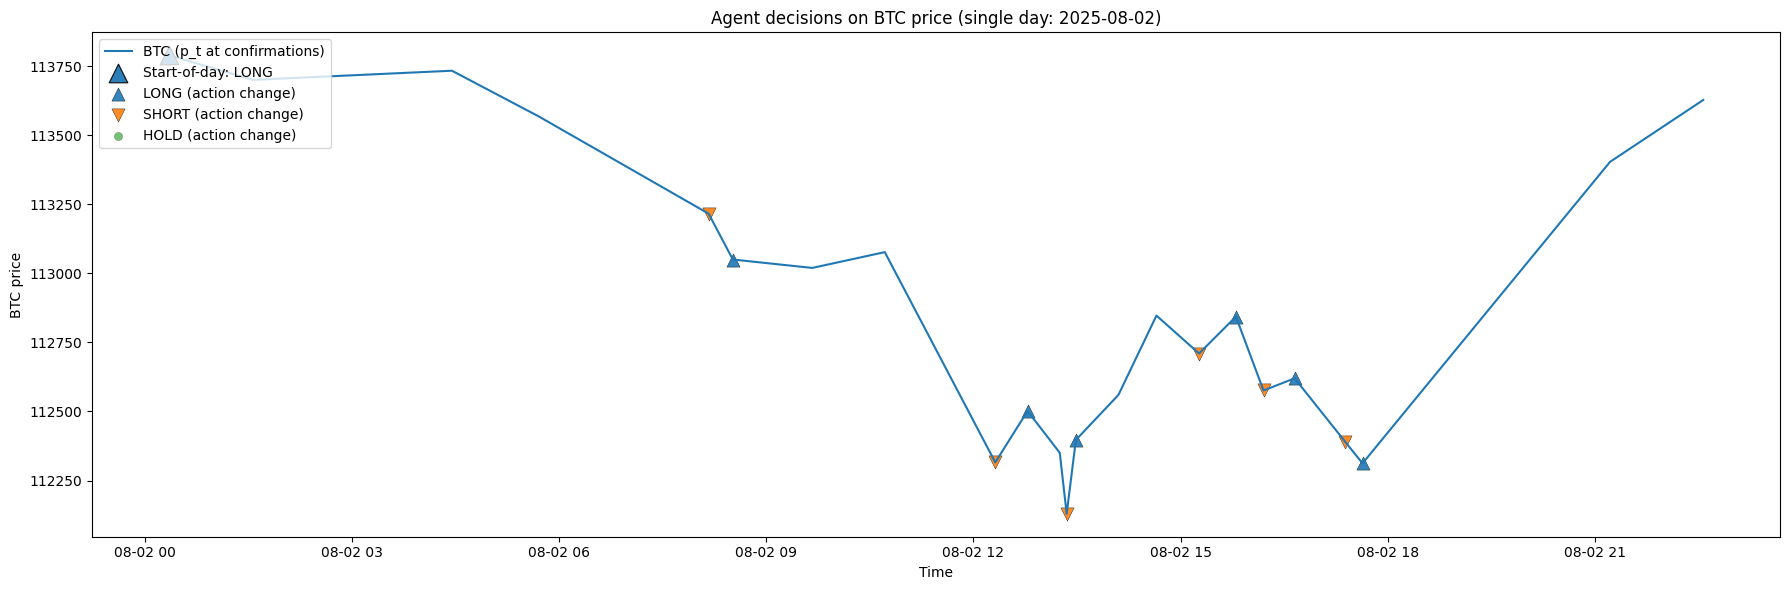

In [11]:
# Plot: BTC price with decision markers (test period)
price_series_time = pd.to_datetime(test_df["t_confirm"].iloc[:T_exec].values)
price_series = test_df["p_t"].iloc[:T_exec].astype(float).values

# Markers: LONG '^', SHORT 'v', HOLD 'o'
mask_long  = exec_log["action_name"] == "LONG"
mask_short = exec_log["action_name"] == "SHORT"
mask_hold  = exec_log["action_name"] == "HOLD"

# Keep marker *colors* consistent across plots (4B-1 and 4B-2)
ACTION_COLOR  = {"LONG": "tab:blue", "SHORT": "tab:orange", "HOLD": "tab:green"}
ACTION_MARKER = {"LONG": "^",         "SHORT": "v",       "HOLD": "o"}

# 4B-1) Full-period, larger figure
plt.figure(figsize=(14, 6))
plt.plot(price_series_time, price_series, label="BTC (p_t at confirmations)")
plt.scatter(
    exec_log.loc[mask_long, "entry_time"],
    exec_log.loc[mask_long, "entry_price"],
    marker=ACTION_MARKER["LONG"],
    color=ACTION_COLOR["LONG"],
    label="LONG entry",
)
plt.scatter(
    exec_log.loc[mask_short, "entry_time"],
    exec_log.loc[mask_short, "entry_price"],
    marker=ACTION_MARKER["SHORT"],
    color=ACTION_COLOR["SHORT"],
    label="SHORT entry",
)
plt.scatter(
    exec_log.loc[mask_hold, "entry_time"],
    exec_log.loc[mask_hold, "entry_price"],
    marker=ACTION_MARKER["HOLD"],
    color=ACTION_COLOR["HOLD"],
    label="HOLD",
)
plt.title("Agent decisions on BTC price (test period)")
plt.xlabel("Time")
plt.ylabel("BTC price")
plt.legend()
plt.tight_layout()
plt.show()

# 4B-2) Randomly plot 5 single days in the test period (action-change markers)
# - Picks 5 random calendar days from the available test timestamps.
# - Plots BTC price within that day and overlays ONLY action changes to reduce clutter.

# Plot only action changes ("entries" into a different action)
exec_plot = exec_log.copy()
exec_plot["action_change"] = exec_plot["action_name"].ne(exec_plot["action_name"].shift(1))
exec_plot = exec_plot.loc[exec_plot["action_change"]].copy()

N_DAYS_TO_PLOT = 5
DAY_SEED = SEED + 999  # reproducible random day selection
rng = np.random.default_rng(DAY_SEED)

# Candidate days from the price series we actually plotted (up to T_exec)
days = pd.to_datetime(price_series_time).normalize()
unique_days = pd.Index(days.unique()).sort_values()

if len(unique_days) == 0:
    print("No days found in test period for plotting.")
else:
    k = int(min(N_DAYS_TO_PLOT, len(unique_days)))
    chosen_days = rng.choice(unique_days.values, size=k, replace=False)
    chosen_days = pd.to_datetime(chosen_days).sort_values()

    for d0 in chosen_days:
        # Day window [d0, d1)
        d0 = pd.to_datetime(d0).normalize()
        d1 = d0 + pd.Timedelta(days=1)

        # Slice price series to that day
        m_price = (price_series_time >= d0) & (price_series_time < d1)
        if m_price.sum() == 0:
            continue

        # Slice ALL decisions to that day (for "start-of-day" action)
        m_all = (exec_log["entry_time"] >= d0) & (exec_log["entry_time"] < d1)
        sub_all = exec_log.loc[m_all].copy()

        # Slice exec_plot (action changes) to that day
        m_exec = (exec_plot["entry_time"] >= d0) & (exec_plot["entry_time"] < d1)
        sub = exec_plot.loc[m_exec].copy()

        plt.figure(figsize=(18, 6))
        plt.plot(price_series_time[m_price], price_series[m_price], label="BTC (p_t at confirmations)", linewidth=1.5)

        # --- Always mark the first action of the day (even if there are no action changes) ---
        # If there are no confirmations that day, sub_all will be empty.
        if len(sub_all) > 0:
            first = sub_all.iloc[0]
            a0 = str(first["action_name"])
            # Distinct marker for the day-start action
            start_marker = ACTION_MARKER.get(a0, "o")
            start_color = ACTION_COLOR.get(a0, "tab:gray")
            plt.scatter(
                [first["entry_time"]],
                [first["entry_price"]],
                marker=start_marker,
                s=180,
                alpha=0.95,
                edgecolors="k",
                linewidths=0.8,
                label=f"Start-of-day: {a0}",
                color=start_color,
                zorder=5,
            )

        # --- Plot action changes (keeps clutter low) ---
        if len(sub):
            mL = sub["action_name"] == "LONG"
            mS = sub["action_name"] == "SHORT"
            mH = sub["action_name"] == "HOLD"

            plt.scatter(
                sub.loc[mL, "entry_time"],
                sub.loc[mL, "entry_price"],
                marker=ACTION_MARKER["LONG"],
                color=ACTION_COLOR["LONG"],
                s=90,
                alpha=0.90,
                edgecolors="k",
                linewidths=0.3,
                label="LONG (action change)",
            )
            plt.scatter(
                sub.loc[mS, "entry_time"],
                sub.loc[mS, "entry_price"],
                marker=ACTION_MARKER["SHORT"],
                color=ACTION_COLOR["SHORT"],
                s=90,
                alpha=0.90,
                edgecolors="k",
                linewidths=0.3,
                label="SHORT (action change)",
            )
            # HOLD can clutter; keep it smaller
            plt.scatter(
                sub.loc[mH, "entry_time"],
                sub.loc[mH, "entry_price"],
                marker=ACTION_MARKER["HOLD"],
                color=ACTION_COLOR["HOLD"],
                s=35,
                alpha=0.65,
                edgecolors="k",
                linewidths=0.2,
                label="HOLD (action change)",
            )

        # If there were confirmations but no action changes, call it out in the title for clarity
        if len(sub_all) > 0 and len(sub) == 0:
            title_suffix = " (no action changes)"
        else:
            title_suffix = ""

        plt.title(f"Agent decisions on BTC price (single day: {d0.date()}){title_suffix}")
        plt.xlabel("Time")
        plt.ylabel("BTC price")
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

### Baseline long-only strategy comparison

=== Baseline: LONG-only ===
Steps: 19665
Avg reward: 3.4443989324266514e-05
Win rate: 0.4979913551995932
Toy equity (start=1): 1.7267563721917205


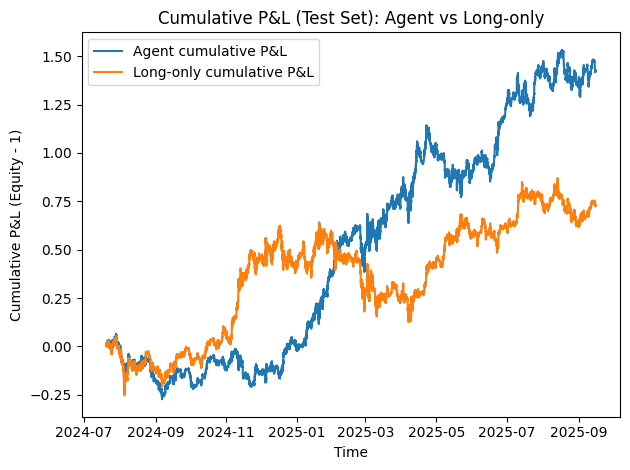

In [12]:
# Long-only means position is always +1 at every decision point.
# Equity compounds with the same rule as the env: equity *= (1 + position * r_step)
# Baseline uses RAW returns for equity calculations
baseline_r = test_df[RAW_RETURN_COL].astype(float).values  # length ~ len(test_df)

# --- Agent equity curve (prefer exec_log because it's aligned to entry/exit interval returns) ---
if ("exec_log" in globals()) and isinstance(exec_log, pd.DataFrame) and ("pnl_frac" in exec_log.columns):
    agent_equity_curve = (1.0 + exec_log["pnl_frac"].astype(float)).cumprod().reset_index(drop=True)
else:
    # fallback: use rollout raw returns directly (must be same length as df_rollout)
    agent_equity_curve = (1.0 + (
        df_rollout["pos"].astype(float).values * df_rollout["ret_next_confirm_raw"].astype(float).values
    )).cumprod()
    agent_equity_curve = pd.Series(agent_equity_curve).reset_index(drop=True)

agent_pnl_curve = agent_equity_curve - 1.0

# --- Baseline: LONG-only aligned to agent curve length ---
T = len(agent_equity_curve)                    # <-- key fix
long_rewards = baseline_r[:T]                  # position=+1
long_equity_curve = pd.Series((1.0 + long_rewards).cumprod()).reset_index(drop=True)
long_pnl_curve = long_equity_curve - 1.0

print("=== Baseline: LONG-only ===")
print("Steps:", T)
print("Avg reward:", float(np.mean(long_rewards)))
print("Win rate:", float(np.mean(long_rewards > 0)))
print("Toy equity (start=1):", float(long_equity_curve.iloc[-1]))

# X-axis aligned to T
if "t_confirm" in test_df.columns:
    x = pd.to_datetime(test_df["t_confirm"].iloc[:T].values)
else:
    x = np.arange(T)

plt.figure()
plt.plot(x, agent_pnl_curve.values, label="Agent cumulative P&L")
plt.plot(x, long_pnl_curve.values, label="Long-only cumulative P&L")
plt.title("Cumulative P&L (Test Set): Agent vs Long-only")
plt.xlabel("Time" if "t_confirm" in test_df.columns else "Step")
plt.ylabel("Cumulative P&L (Equity - 1)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
def equity_from_rets(r) -> float:
    r = pd.Series(r).dropna().astype(float).values
    return float(np.exp(np.sum(np.log1p(r))))

# IMPORTANT: equity/baselines should use RAW returns (not scaled PPO reward)
print("\n=== Sanity: Long-only equity & mean return (RAW) ===")
print("TRAIN long-only equity:", equity_from_rets(train_df[RAW_RETURN_COL]))
print("TEST  long-only equity:", equity_from_rets(test_df[RAW_RETURN_COL]))
print("TRAIN mean raw ret:", float(train_df[RAW_RETURN_COL].mean()))
print("TEST  mean raw ret:", float(test_df[RAW_RETURN_COL].mean()))

# Also show the scaled reward mean (what PPO sees)
print("TRAIN mean scaled reward:", float(train_df[REWARD_COL].mean()))
print("TEST  mean scaled reward:", float(test_df[REWARD_COL].mean()))


# 6A) Baseline comparison: LONG-only vs SHORT-only vs HOLD-only (RAW)
# This diagnoses whether the market regime differs between TRAIN and TEST.

def _eq_from_raw(r) -> float:
    r = pd.Series(r).dropna().astype(float).values
    return float(np.exp(np.sum(np.log1p(r))))

def baseline_report(df_: pd.DataFrame, name: str):
    r = df_[RAW_RETURN_COL].dropna().astype(float)
    print(f"=== Baseline report ({name}) ===")
    print("n:", int(r.shape[0]))
    print("mean raw ret:", float(r.mean()) if len(r) else np.nan)
    print("LONG-only equity :", _eq_from_raw(r))
    print("SHORT-only equity:", _eq_from_raw(-r))
    print("HOLD-only equity :", 1.0)

baseline_report(train_df, "TRAIN")
baseline_report(test_df,  "TEST")


=== Sanity: Long-only equity & mean return (RAW) ===
TRAIN long-only equity: 2.778000437282599
TEST  long-only equity: 1.7312161470356664
TRAIN mean raw ret: 2.164543789420544e-05
TEST  mean raw ret: 3.457356844625141e-05
TRAIN mean scaled reward: 0.002164543789420545
TEST  mean scaled reward: 0.003457356844625141
=== Baseline report (TRAIN) ===
n: 94724
mean raw ret: 2.164543789420544e-05
LONG-only equity : 2.778000437282599
SHORT-only equity: 0.04611616632261428
HOLD-only equity : 1.0
=== Baseline report (TEST) ===
n: 19666
mean raw ret: 3.457356844625141e-05
LONG-only equity : 1.7312161470356664
SHORT-only equity: 0.44432581943493704
HOLD-only equity : 1.0


In [14]:
# 6B) In-sample (TRAIN) evaluation of the learned policy (same VecNormalize stats)
_eval_env_train = DummyVecEnv([
    lambda: DCEventTradingEnv(
        train_df,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        # Option C: rolling drawdown penalty
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        # Option D: dynamic HOLD penalty
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
    )
])
_eval_env_train = VecNormalize(_eval_env_train, training=False, norm_obs=True, norm_reward=False)
_eval_env_train.seed(SEED + 4)
_eval_env_train.obs_rms = train_env.obs_rms

df_rollout_tr, per_action_tr, overall_tr = evaluate_with_action_stats(model, _eval_env_train, deterministic=True)
print("=== Sanity: TRAIN policy action stats (deterministic) ===")
print(per_action_tr)
print("TRAIN policy equity (env):", _eval_env_train.venv.envs[0].equity)

=== Sanity: TRAIN policy action stats (deterministic) ===
                 n      freq  avg_reward  med_reward  win_rate  \
action_name                                                      
HOLD          7343  0.077520   -0.021489   -0.020000  0.000000   
LONG         46629  0.492262    0.000202    0.000000  0.498960   
SHORT        40752  0.430218   -0.001651    0.008932  0.507607   

             avg_pnl_frac_raw  med_pnl_frac_raw  pnl_win_rate_raw  \
action_name                                                         
HOLD                 0.000000          0.000000          0.000000   
LONG                 0.000046          0.000010          0.500590   
SHORT                0.000007          0.000108          0.509398   

             avg_raw_ret_unadj  
action_name                     
HOLD                  0.000025  
LONG                  0.000046  
SHORT                -0.000007  
TRAIN policy equity (env): 1.0


In [15]:
# In-sample (TRAIN) evaluation of the learned policy (same VecNormalize stats)
_eval_env_s = DummyVecEnv([
    lambda: DCEventTradingEnv(
        test_df,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        # Option C: rolling drawdown penalty
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        # Option D: dynamic HOLD penalty
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
    )
])
_eval_env_s = VecNormalize(_eval_env_s, training=False, norm_obs=True, norm_reward=False)
_eval_env_s.seed(SEED + 5)
_eval_env_s.obs_rms = train_env.obs_rms

df_rollout_s, per_action_s, overall_s = evaluate_with_action_stats(model, _eval_env_s, deterministic=False)
print("\n=== Sanity: stochastic action stats ===")
print(per_action_s)


=== Sanity: stochastic action stats ===
                n      freq  avg_reward  med_reward  win_rate  \
action_name                                                     
HOLD         3878  0.197193   -0.020149   -0.020000  0.000000   
LONG         9442  0.480118    0.004151   -0.001515  0.498623   
SHORT        6346  0.322689   -0.002879    0.012217  0.511503   

             avg_pnl_frac_raw  med_pnl_frac_raw  pnl_win_rate_raw  \
action_name                                                         
HOLD                 0.000000          0.000000          0.000000   
LONG                 0.000049         -0.000009          0.499153   
SHORT               -0.000020          0.000130          0.512922   

             avg_raw_ret_unadj  
action_name                     
HOLD                  0.000023  
LONG                  0.000049  
SHORT                 0.000020  


In [16]:
df_rollout_det, per_action_det, overall_det = evaluate_with_action_stats(model, _eval_env, deterministic=True)
print("\n=== Sanity: deterministic action stats ===")
print(per_action_det)


=== Sanity: deterministic action stats ===
                 n      freq  avg_reward  med_reward  win_rate  \
action_name                                                      
HOLD           100  0.005085   -0.019849   -0.020000  0.000000   
LONG         13142  0.668260    0.005582    0.003809  0.503424   
SHORT         6424  0.326655    0.002089    0.015609  0.514477   

             avg_pnl_frac_raw  med_pnl_frac_raw  pnl_win_rate_raw  \
action_name                                                         
HOLD                 0.000000          0.000000          0.000000   
LONG                 0.000063          0.000039          0.503652   
SHORT                0.000030          0.000163          0.515411   

             avg_raw_ret_unadj  
action_name                     
HOLD                  0.000476  
LONG                  0.000063  
SHORT                -0.000030  


In [17]:
# Random-start evaluation windows 
rand_eval = evaluate_random_start_episodes(
    model,
    _eval_env,            # VecNormalize(training=False) with obs_rms already set
    n_episodes=10,
    horizon=5000,
    deterministic=True,
    seed=SEED + 100,
)
print("\n=== Random-start eval (10 episodes, horizon=2000) ===")
for k, v in rand_eval.items():
    print(f"{k}: {v}")


=== Random-start eval (10 episodes, horizon=2000) ===
n_episodes: 10
horizon: 5000
mean_total_reward: 23.107238922344923
std_total_reward: 29.5352751952229
mean_equity_end: 1.324746384025993
std_equity_end: 0.3746873890937374


In [18]:
# Check action probabilities under the learned policy (first ~10000 test steps) 
_prob_env = DummyVecEnv([
    lambda: DCEventTradingEnv(
        test_df,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        # Option C: rolling drawdown penalty
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
    )
])
_prob_env = VecNormalize(_prob_env, training=False, norm_obs=True, norm_reward=False)
_prob_env.seed(SEED + 6)
_prob_env.obs_rms = train_env.obs_rms

obs = _prob_env.reset()  # VecEnv obs shape: (1, obs_dim)
probs = []

for _ in range(10000):
    # SB3-safe: converts obs and moves to correct device
    obs_t, _ = model.policy.obs_to_tensor(obs)
    with torch.no_grad():
        dist = model.policy.get_distribution(obs_t)
        p = dist.distribution.probs.detach().cpu().numpy().ravel()  # [p_short,p_hold,p_long]
    probs.append(p)

    action, _ = model.predict(obs, deterministic=True)
    obs, r, dones, infos = _prob_env.step(action)
    if bool(dones[0]):
        break

probs = np.vstack(probs) if len(probs) else np.zeros((0, 3))
print("\n=== Sanity: action probabilities (first 10000 steps) ===")
if len(probs):
    print("Mean probs [SHORT,HOLD,LONG]:", probs.mean(axis=0))
    print("Median probs:", np.median(probs, axis=0))
else:
    print("No steps collected (env terminated immediately).")


=== Sanity: action probabilities (first 10000 steps) ===
Mean probs [SHORT,HOLD,LONG]: [0.35323533 0.18905188 0.45771334]
Median probs: [0.30712682 0.17783022 0.48202792]


In [19]:
# Check for clipping / distribution shift
cols = list(STATE_COLS_SAFE)

def _describe(df_: pd.DataFrame, cols_: list[str]) -> pd.DataFrame:
    d = df_[cols_].astype(float).describe(percentiles=[0.01, 0.5, 0.99]).T
    # keep key stats
    out = d[["mean", "std", "min", "1%", "50%", "99%", "max"]].copy()
    out = out.rename(columns={"50%": "median", "1%": "p01", "99%": "p99"})
    return out

train_stats = _describe(train_df, cols)
test_stats  = _describe(test_df, cols)

shift = train_stats.join(test_stats, lsuffix="_train", rsuffix="_test")

# Classic z-shift using TRAIN std
eps = 1e-12
shift["z_shift"] = (shift["mean_test"] - shift["mean_train"]) / (shift["std_train"] + eps)

# Robust z-shift using median and IQR (approx std ≈ IQR/1.349)
iqr_train = (shift["p99_train"] - shift["p01_train"]).replace(0, np.nan)
robust_scale = (iqr_train / 1.349).fillna(shift["std_train"]).fillna(0.0) + eps
shift["z_shift_robust"] = (shift["median_test"] - shift["median_train"]) / robust_scale

# Helpful extra: range overlap / clipping risk
shift["train_range"] = shift["min_train"].round(6).astype(str) + " .. " + shift["max_train"].round(6).astype(str)
shift["test_range"]  = shift["min_test"].round(6).astype(str)  + " .. " + shift["max_test"].round(6).astype(str)

print("\n=== Top shifts by |z_shift_robust| ===")
print(
    shift.sort_values("z_shift_robust", key=lambda s: s.abs(), ascending=False)
         [["mean_train","mean_test","std_train","std_test","z_shift","z_shift_robust","train_range","test_range"]]
         .head(10)
)

print("\n=== Top shifts by |z_shift| (classic) ===")
print(
    shift.sort_values("z_shift", key=lambda s: s.abs(), ascending=False)
         [["mean_train","mean_test","std_train","std_test","z_shift","z_shift_robust","train_range","test_range"]]
         .head(10)
)


=== Top shifts by |z_shift_robust| ===
                                    mean_train   mean_test   std_train  \
vol_60d                               0.001101    0.000725    0.000365   
vol_30d                               0.001122    0.000725    0.000452   
tickvol_avg_60d                      35.035698   62.037751   35.853707   
tickvol_avg_1h                       46.253315   77.491440   56.638439   
tickvol_avg_30d                      36.426743   59.866605   37.577149   
tickvol_avg_1d                       41.753271   65.441480   46.533997   
vol_1d                                0.001257    0.000787    0.000890   
vol_1h                                0.001346    0.000907    0.001188   
n_obs_between_priorextreme_confirm    7.859075   10.709905   12.870828   
dt_prior_to_confirm_sec             474.377138  653.049934  788.625037   

                                      std_test   z_shift  z_shift_robust  \
vol_60d                               0.000120 -1.027448       -0.223

Takeaways: 